# Predicting Newsletter Subscription from Player Characteristic 
**Introduction**

    Background

In the gaming world, keeping players engaged and interested is a key focus for game developers. One way companies can do this is through newsletters, which share updates and new events with players. Subscribing to a newsletter often shows that a player is more engaged and invested in the game community. 
By studying which players are likely to subscribe, game developers and marketers can better understand what attracts players best. This information can help them save resources and time by focusing mainly on the characteristics that maintains player engagement. 

    Question
*Can a player’s experience level and average session time predict whether they subscribe to the game’s newsletter?*

To explore this question, we use two datasets. The players dataset includes each player’s experience level and whether or not they subscribed to the newsletter. The sessions dataset contains information about individual play sessions, including session duration. We calculate each player’s average session time using this data and then merge it with the player information.

    Dataset Description

The *players.csv* dataset contains 196 observations and 7 variables. The variables include a mix of data types:

**Object (String)**: `experience`, `hashedEmail`, `name`, `gender`

**Boolean**: `subscribe`

**Float64 (Numeric)**: `played_hours`, `age`

The dataset has 2 missing values in the age variable.

A notable characteristic of the dataset is that approximately 75% of players have played fewer than 0.6 hours, indicating a highly right-skewed distribution of gameplay time. This may affect how experience level or session-based predictions are interpreted. Furthermore, The dataset appears to be self-reported, meaning that all values rely on the players’ honesty and accuracy. As a result, the dataset may contain biases such as underreporting, overreporting, or inconsistent interpretations of survey questions, all of which can potentially limit the reliability of subsequent analysis.

The *sessions.csv* dataset contains 1535 observations and 5 variables. The variables include a mix of data types: 

**Object (String)**: `hashedEmail`,`start_time`,`end_time`

**Float64 (Numeric)**: `original_start_time`, `original_end_time`

The dataset has 2 missing observations for both end_time and original_end_time, which may introduce small errors in analysis if these missing values are not handled appropriately. Additionally, the time-related variables are stored in two different format; the start_time and end_time are in string format ("dd/mm/yyyy hh:mm") while original_start_time & original_end_time are in numeric milliseconds which problems if not converted properly.

The merged dataset *clean_data*, contains 124 observations and 3 variables, `subscribe`, `session_time`, and `experience`. Of the three variable, we will use `session_time` and `experience` as our predictors to predict `subscribe` as the response variable. 

In [2]:
#load libraries
library(tidyverse)
library(dplyr)
library(repr)
library(tidymodels)
library(GGally)
library(ISLR)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

In [3]:
#read in players dataset
url<-"https://raw.githubusercontent.com/garyzhang25/DSI-100-Individual-Project/refs/heads/main/players.csv"
download.file(url, "players.csv")
players_data<-read_csv("players.csv")
head(players_data)

# max, min, mean of hours spent in game and the age
players_max<-players_data |>
select(played_hours, age) |>
map_df(max, na.rm=TRUE)
players_max

players_min<-players_data |>
select(played_hours, age) |>
map_df(min, na.rm=TRUE)
players_min

players_mean<-players_data |>
select(played_hours, age) |>
map_df(mean, na.rm=TRUE)
players_mean

# Each experience level and their count 
players_experience_count<-players_data |>
group_by(experience) |>
summarize(count=n()) |>
arrange(by=desc(count)) 
players_experience_count

# Proportion of subscribers
players_sub_count<- players_data |>
group_by(subscribe) |>
summarize(count=n()) |>
arrange(by=desc(count))
players_sub_count

#genders and count
players_gender_count<- players_data |>
group_by(gender) |>
summarize(count=n()) |>
arrange(by=desc(count))
players_gender_count

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


played_hours,age
<dbl>,<dbl>
223.1,58


played_hours,age
<dbl>,<dbl>
0,9


played_hours,age
<dbl>,<dbl>
5.845918,21.13918


experience,count
<chr>,<int>
Amateur,63
Veteran,48
Regular,36
Beginner,35
Pro,14


subscribe,count
<lgl>,<int>
TRUE,144
FALSE,52


gender,count
<chr>,<int>
Male,124
Female,37
Non-binary,15
Prefer not to say,11
Two-Spirited,6
Agender,2
Other,1


In [4]:
url<-"https://raw.githubusercontent.com/garyzhang25/DSI-100-Individual-Project/refs/heads/main/sessions.csv"
download.file(url,"sessions.csv")
sessions_data<-read_csv("sessions.csv")
head(sessions_data)

session_times <- sessions_data |>
  select(start_time, end_time) |>
  separate(start_time,
           into = c("start_date", "start_time"),
           sep = " ",
           convert = TRUE) |>
  separate(end_time, 
           into = c("end_date", "end_time"),
           sep = " ",
           convert = TRUE) |>
  separate(start_time,  
           into = c("start_hour", "start_minute"),
           sep = ":", 
           convert = TRUE) |>
  separate(end_time, 
           into = c("end_hour", "end_minute"),
           sep = ":",
           convert = TRUE) |>
  mutate(start_minute_of_day = start_hour*60 + start_minute) |>
  mutate(end_minute_of_day = end_hour*60 + end_minute) |>
  mutate(session_minutes = end_minute_of_day - start_minute_of_day) |>
  select(session_minutes) |>
  filter(session_minutes >= 0) 
head(session_times)

Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


session_minutes
<dbl>
12
13
23
36
11
122


In [5]:
# max, min, mean of seession time
session_times_max<-session_times |>
map_df(max, na.rm=TRUE)
session_times_max

session_times_min<-session_times |>
map_df(min, na.rm=TRUE)
session_times_min

session_times_average<-session_times |>
map_df(mean, na.rm=TRUE)
session_times_average

session_minutes
<dbl>
256


session_minutes
<dbl>
3


session_minutes
<dbl>
46.85982


In [6]:
#combined data frames and added session time
merged_data <- merge(sessions_data, players_data,by = "hashedEmail")|>
    separate(start_time,
           into = c("start_date", "start_time"),
           sep = " ",
           convert = TRUE) |>
  separate(end_time, 
           into = c("end_date", "end_time"),
           sep = " ",
           convert = TRUE) |>
  separate(start_time,  
           into = c("start_hour", "start_minute"),
           sep = ":", 
           convert = TRUE) |>
  separate(end_time, 
           into = c("end_hour", "end_minute"),
           sep = ":",
           convert = TRUE) |>
  mutate(start_minute_of_day = start_hour*60 + start_minute) |>
  mutate(end_minute_of_day = end_hour*60 + end_minute) |>
  mutate(session_minutes = end_minute_of_day - start_minute_of_day) |>
  filter(session_minutes >= 0) |>
  select(name, session_minutes, experience, subscribe)|>
  group_by(name) |>
  summarize(session_time = mean(session_minutes))

#one name per session_time, select useful columns, and convert subscribe to factor type
clean_data <- merge(players_data, merged_data, by = "name")|>
  select(experience, session_time, subscribe) |>
  mutate(subscribe = as_factor(subscribe))|>
  mutate(subscribe = fct_recode(subscribe, "Yes" = "TRUE", "No" = "FALSE"))
#head(clean_data)
clean_data

experience,session_time,subscribe
<chr>,<dbl>,<fct>
Beginner,18.000000,Yes
Amateur,28.000000,Yes
Pro,15.000000,Yes
Veteran,19.666667,No
Regular,150.025641,Yes
Amateur,28.357724,Yes
Beginner,116.000000,No
Beginner,49.000000,Yes
Amateur,12.000000,No


In [7]:
num_obs <- nrow(clean_data)
clean_data |>
  group_by(subscribe) |>
  summarize(
    count = n(),
    percentage = n() / num_obs * 100)

subscribe,count,percentage
<fct>,<int>,<dbl>
No,32,25.80645
Yes,92,74.19355


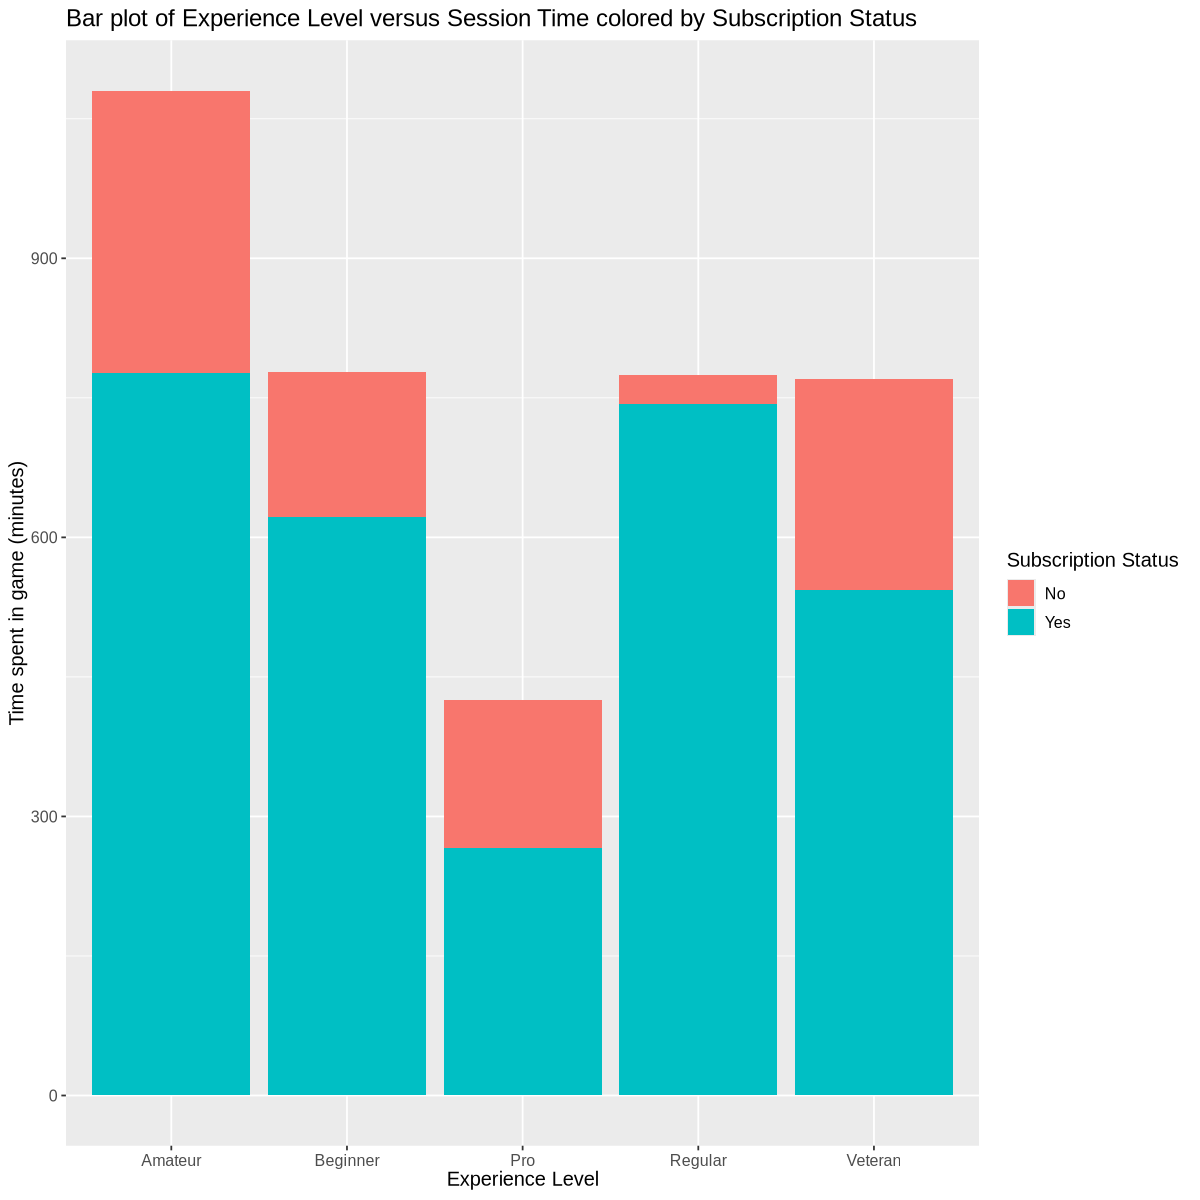

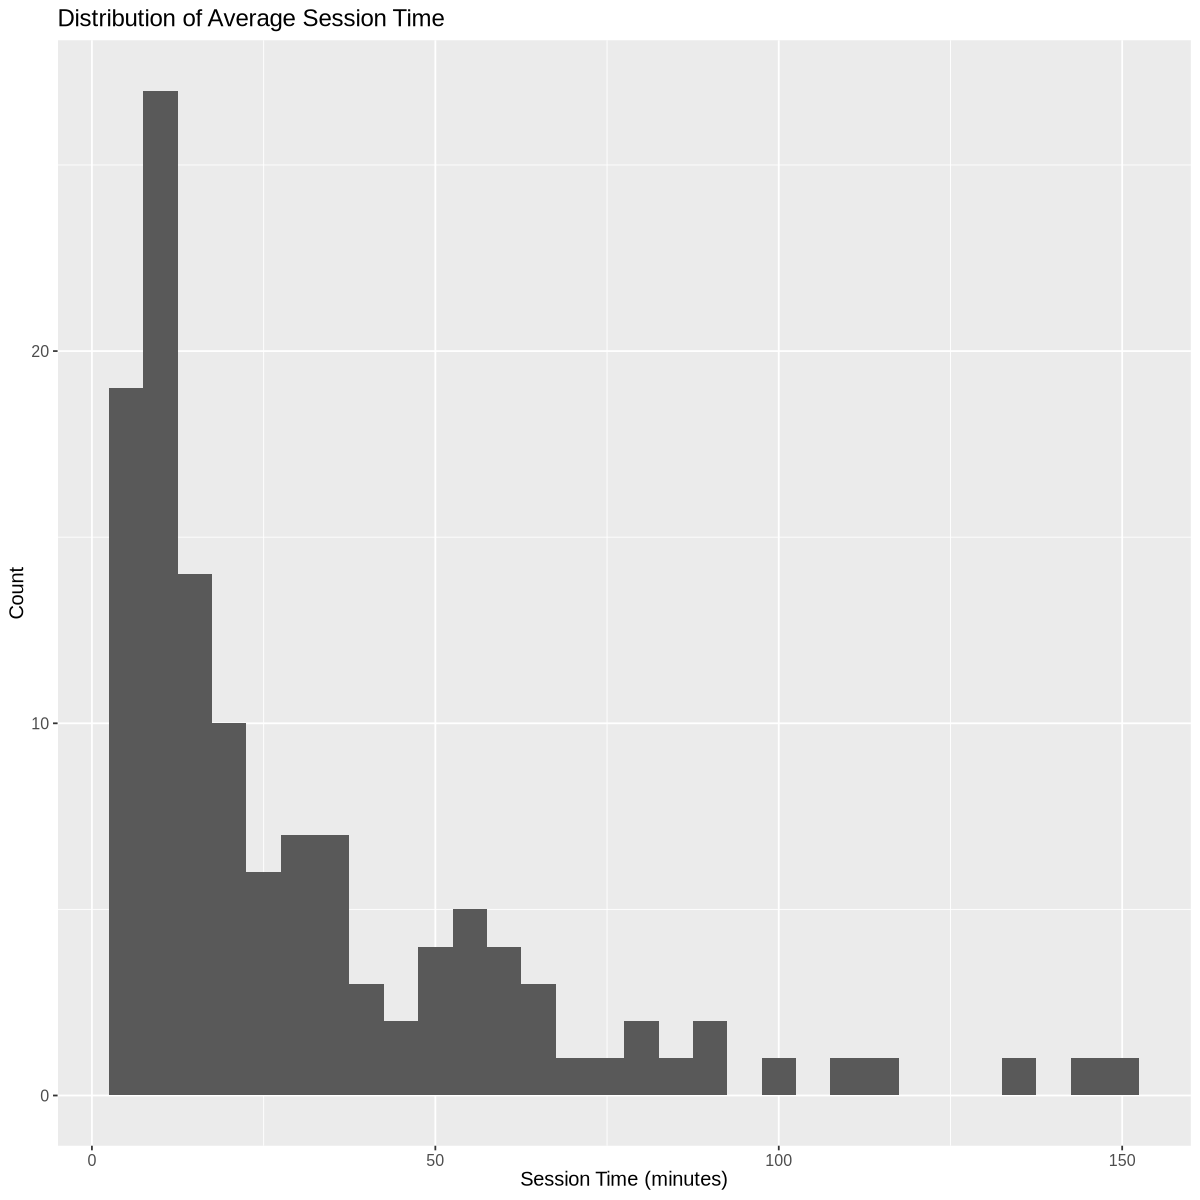

In [8]:

vis_sub <- clean_data |>
  ggplot(aes(x = experience, y = session_time, fill = subscribe)) +
  geom_bar(stat = "identity") +
  labs(x = "Experience Level",
       y = "Time spent in game (minutes)",
       fill = "Subscription Status" ) +
theme(text = element_text(size = 12)) +
  ggtitle("Bar plot of Experience Level versus Session Time colored by Subscription Status")+
theme(text = element_text(size = 12))
options(repr.plot.width = 10, repr.plot.height = 10)
vis_sub
# session time distribution
session_time_dist <- ggplot(clean_data, aes(x = session_time)) +
  geom_histogram(bins = 20, binwidth = 5) +
  labs(title = "Distribution of Average Session Time",
    x = "Session Time (minutes)",
    y = "Count") +
theme(text = element_text(size = 12))

session_time_dist

The bar plot of experience level versus average session time, colored by subscription status, shows that more experienced players generally tend to have longer session times, and subscribers often appear to play slightly longer than non-subscribers within the same experience group. To better understand the overall distribution of play duration, we also created a histogram of average session time. Most players have relatively short to moderate session lengths, with fewer players exhibiting very long sessions, resulting in a right-skewed distribution.